# Feature Exploration

This notebook loads the dataset and explores it's features to gather insights and make decisions about the feature set for training the final regression model.

## Data Loading

This section loads the CSV dataset into a pandas dataframe. The price feature (the target variable) is split from the predictor features.

In [1]:
import numpy as np
import pandas as pd

data = pd.read_csv('../data/house_data.csv')  # Load the dataset from the file and store it as a pandas dataframe called data

y=data['price']               # Create a pandas series (y) to store the prices for all of the houses in the dataset
X=data.copy()                 # Create a copy of the pandas dataframe (data) called X
X=X.drop(['price'],axis=1)    # Remove the price column from the X dataframe
X.head()                      # Display the first few rows of the X dataframe along with the column headers

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Exploratory Data Analysis

The purpose of this section is to understand the features in the dataset. 

In [2]:
'''
Show:
- The number of entries (rows)
- The number of populated (non-null) entries in each column
- The data types for each column 
- The total size of the dataframe in terms of memory
'''
X.info()  

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   bedrooms       21613 non-null  int64  
 3   bathrooms      21613 non-null  float64
 4   sqft_living    21613 non-null  int64  
 5   sqft_lot       21613 non-null  int64  
 6   floors         21613 non-null  float64
 7   waterfront     21613 non-null  int64  
 8   view           21613 non-null  int64  
 9   condition      21613 non-null  int64  
 10  grade          21613 non-null  int64  
 11  sqft_above     21613 non-null  int64  
 12  sqft_basement  21613 non-null  int64  
 13  yr_built       21613 non-null  int64  
 14  yr_renovated   21613 non-null  int64  
 15  zipcode        21613 non-null  int64  
 16  lat            21613 non-null  float64
 17  long           21613 non-null  float64
 18  sqft_living15  21

There are over 21.6k instances in the dataset, each with 20 features (not including price) and no null entries. This dataframe is 3.3MB and it contains float64 and int64 datatypes, as well as datetime objects for the date column.

Feature | Explanation
--- | ---
id | Unique numeric identifier of the house.
date | Date when the house was sold.
price | House sale price (target variable).
bedrooms | Number of bedrooms.
bathrooms | Number of bathrooms (following the North American standard).
sqft_living | Floor area of the house (square feet).
sqft_lot | Area of the plot of land (square feet).
floors | Number of floors/levels.
waterfront | Whether or not the house is on the waterfront (bool).
 view | Has the house been viewed (bool).
condition | Overall condition (1-5).
grade | Grade given to the housing unit, based on King County grading system (1-11).
sqft_above | Floor area of the house excluding the basement (square feet).
sqft_basement | Floor are of the basement (square feet).
yr_built | Year the house was build.
yr_renovated | Year the house was renovated.
zipcode | The zipcode in the property address.
lat | Latitude of the location of the house.
long | Longitude of the location of the house.
sqft_living15 | Floor area of the house in 2015 (implies some renovations)
sqft_lot15 | Area of the plot of land in 2015 (implies some renovations)

### Price Distribution

In [3]:
y.describe()

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

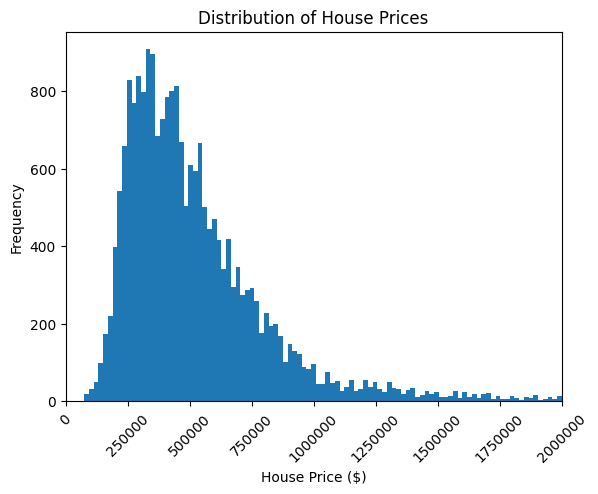

In [4]:
import matplotlib.pyplot as plt

plt.title("Distribution of House Prices")

plt.xlim(0, 2000000)                # Only show house prices up to $2M
plt.xlabel("House Price ($)")
plt.ticklabel_format(style='plain') # Disable scientific notation for x axis ticks
plt.xticks(rotation=45)

plt.ylabel("Frequency")

plt.hist(y, bins=400)            

plt.show()

The house prices follow a standard distribution, which is heavily right-skewed (positive skew) with a peak around $300,000. The true extent of the outliers is not shown because the X axis limit has been set at $2M for readability. There are outlier values up to nearly $8M. The vast majority of houses sold for between $175k and $1M.

### Feature Distribution

In [5]:

from dateutil import parser

print("\nRange of House Sale Dates:")
print("-" * 40)
print(f"Earliest: {parser.parse(X['date'].min()).date().strftime("%d/%m/%Y")}") 
print(f"Latest:   {parser.parse(X['date'].max()).date().strftime("%d/%m/%Y")}")

print("\nFloat Features:")
print("-" * 40)
print(f"Floors Values: ", end="")
print(*sorted(X['floors'].unique()))
print(f"Bathrooms Values: ", end="")
print(*sorted(X['bathrooms'].unique()))


Range of House Sale Dates:
----------------------------------------
Earliest: 02/05/2014
Latest:   27/05/2015

Float Features:
----------------------------------------
Floors Values: 1.0 1.5 2.0 2.5 3.0 3.5
Bathrooms Values: 0.0 0.5 0.75 1.0 1.25 1.5 1.75 2.0 2.25 2.5 2.75 3.0 3.25 3.5 3.75 4.0 4.25 4.5 4.75 5.0 5.25 5.5 5.75 6.0 6.25 6.5 6.75 7.5 7.75 8.0


All instances in the dataset were house sales from May 2014 to May 2015. This highlights that any model trained on this data may not be accurate in predicting current prices.

At first, the float features appear odd because most would expect the number of floors and number of bathrooms to be integer values. However, they each follow a system. The number of floors represents the number of storeys, with 0.5 being added for partial floors or attic conversions. The number of bathrooms follow the North American standard:

Value | Type
--- | ---
0.5 | Toilet & Sink
0.75 | Toilet, Sink & Shower
1 | Toilet, Sink & Bath

These features will be retained as is. Assuming the data provided at inference time follows this same system, the model should interpret it correctly. Since this model will be specific to the US market, it is presumed that the end user will be aware of the bathroom system. Either way, they should be guided so they input the correct data.

In [6]:
'''
For each column show:
- count: The number of populated (non-null) entries
- mean: The average value
- std: The variation (standard deviation) of the values
- min: The smallest value
- 25%: The first quartile / 25th percentile
- 50%: The second quartile / 50th percentile / median
- 75%: The third quartile / 75th percentile
- max: The largest value
'''
X.describe()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


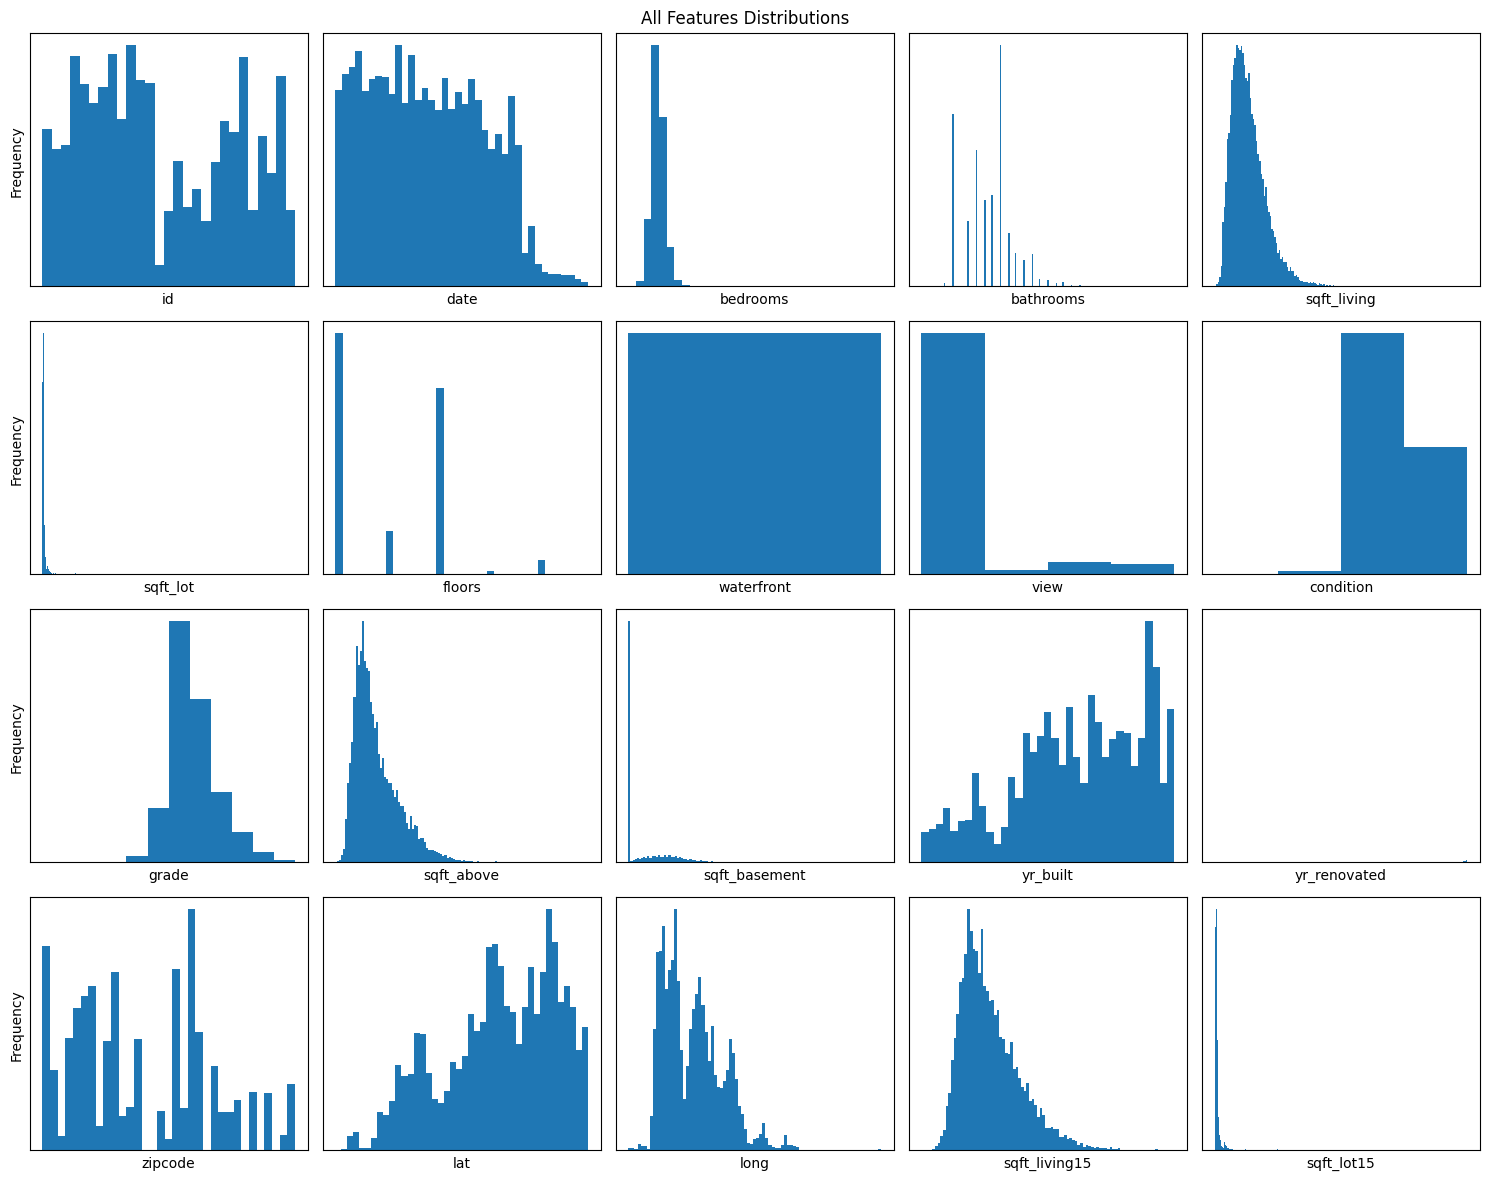

In [7]:
subplot_h = 3
subplot_w = 3

rows = 4
cols = 5

plt.figure(figsize=(subplot_w*cols, (subplot_h*rows)))    # Set the size of the figure

plt.suptitle("All Features Distributions")

for i, column in enumerate(X.columns): # Go through every feature
    
    # Only show a ylabel at the start of each row
    if (i-1) % cols == 0:           
        plt.ylabel("Frequency")
        
    # Plot a histogram of the feature
    plt.subplot(4, 5, i+1)
    plt.hist(X[column], bins="auto")   
    
    # Set the xlabel to show the feature name
    plt.xlabel(column)   
    
    # Remove the ticks
    plt.xticks([])                 
    plt.yticks([])

plt.tight_layout()
plt.show()

The number of bedrooms ranges from 0 to 33 and the number of bathrooms ranges from 0 to 8. This shows the dataset contains some large properties but also some which may be invalid due to having 0 bedrooms and/or bathrooms. Any invalid properties should be dropped from the dataset. On average though, houses have 3 bedrooms and 2 bathrooms.

The houses were all built between 1900 and 2015, with the average house being built in 1971. The lack of historic properties again highlights that this is a US based dataset and models may not generalise to other locations where the housing stock is much older. Overall though, there is a upward trend with more houses being built in later years. This could correlate with premium price for rarer, historic properties although at this point, this is purely speculation.

The year renovated feature has the potential to be useful however, houses which haven't been renovated or haven't had their renovation year recorded, are simply input as the year renovated being 0. The statistics show that most houses in the dataset are recorded as a 0. This feature may not carry much predictive signal. It is possible that a simpler bool indicating renovated or not renovated may be more meaningful.

There are multiple features relating to the floor or lot area. At a glance though, this shows that all of the properties have between 290 and 13,540 square feet of floor area but the average house has 1,910 square feet of space. Again this shows there are some large outliers at the upper end.

The condition and grade both show a standard distribution with scores overall being slightly above average.

The Zipcode feature does not show insightful statistics because the data is categorical. The ID is meaningless as it is a set of unique identifiers, not numerical property data.

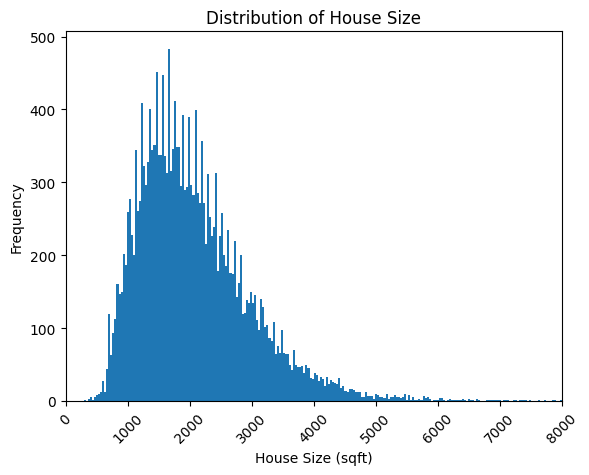

In [8]:
import matplotlib.pyplot as plt

plt.title("Distribution of House Size")

plt.xlim(0, 8000)                # Only show house prices up to 8000 sqft
plt.xlabel("House Size (sqft)")
plt.ticklabel_format(style='plain') # Disable scientific notation for x axis ticks
plt.xticks(rotation=45)

plt.ylabel("Frequency")

plt.hist(X['sqft_living'], bins=400)            

plt.show()

This histogram shows that the distribution of house size is also a standard distribution which is right-skewed. The peak is around 1700 sqft. Again, the values go higher than is shown on the plot (up to 13,500 sqft) but the x axis scale is limited to 8,000 to improve the readability of the plot. The vast majority of houses have between 500 and 4000 sqft of living area. The similarity in the distribution of house prices and sizes may indicate that there is a correlation between them.

In [9]:
import plotly.express as px

fig = px.scatter_map(
    data,
    lat="lat",
    lon="long",
    color=np.log10(data["price"]),
    zoom=9,
    height=800,
    title="House Prices by Location"
)


fig.update_coloraxes(
    colorbar_title="Price ($)",
    colorbar_tickvals=np.log10([100000, 200000, 500000, 1000000, 2000000, 5000000]),
    colorbar_ticktext=["100k", "200k", "500k", "1M", "2M", "5M"]
)

fig.write_image("../images/plotly_price_map.png", scale=3)

fig.show()

/var/folders/rj/ct7r8s153yjbc39mkq2n1f700000gn/T/ipykernel_93639/1029064094.py:20: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image("../images/plotly_price_map.png", scale=3)


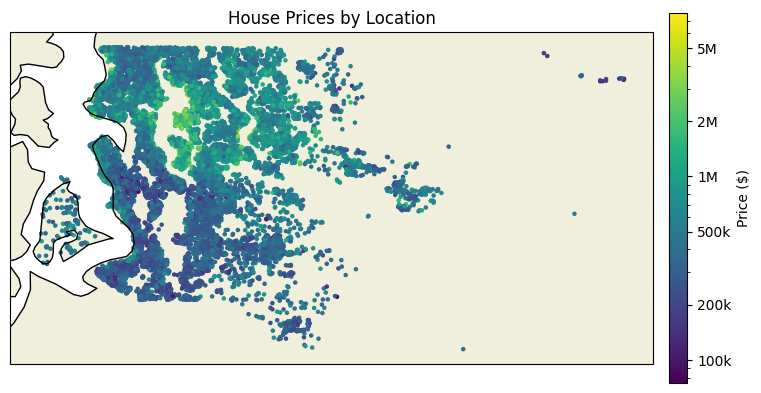

In [10]:

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)

scatter = ax.scatter(
    data["long"],
    data["lat"],
    c=data["price"],
    s=5,  # Small points
    cmap="viridis",
    norm=LogNorm(), # log scale
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(scatter, label="Price ($)", shrink=0.6, pad=0.02)
tick_vals = [100_000, 200_000, 500_000, 1_000_000, 2_000_000, 5_000_000]
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(["100k", "200k", "500k", "1M", "2M", "5M"])

plt.title("House Prices by Location")

plt.savefig("../images/cartopy_price_map.png", dpi=300, bbox_inches="tight")
plt.show()

Both of the above plots show the geographical distribution of the properties and the colour shows how the location correlates with the price. The first impression is that the properties are all within a region of the USA, specifically Kings County, Washington state, which includes the state capital, Seattle. This again highlights that any model trained on this data is likely to learn the market trends which are specific to this geographic region and may not be suitable for predicting prices elsewhere.

In terms of trends, the data does show that higher value properties are concentrated in Seattle (Central District), Bellvue, Mercer Island and the West coastline. More affordable housing is found in the south of the county. The handful of rural outliers also seem to be priced at the lower end of the market.

EDA Summary
- The dataset contains approximately 21,600 house sales from King County, Washington between May 2014 and May 2015.
- House prices are heavily right-skewed, with a small number of multi-million-dollar properties.
- House size distributions show a similar right-skewed pattern, suggesting a relationship between size and price.
- Location appears to have a significant impact on price, with higher-value properties concentrated around Seattle, Bellevue and Mercer Island.
- Some features including bathrooms, floors and renovation year contain more nuance than expected in how they are recorded.
- The dataset represents a single geographic region and time period, meaning any trained model may not generalise well to other housing markets.

## Correlation Analysis

Now the features have been understood, this section analyses how they each correlate with price. If there are strong correlations, the feature is further examined to see the underlying pattern in its relationship with property value.

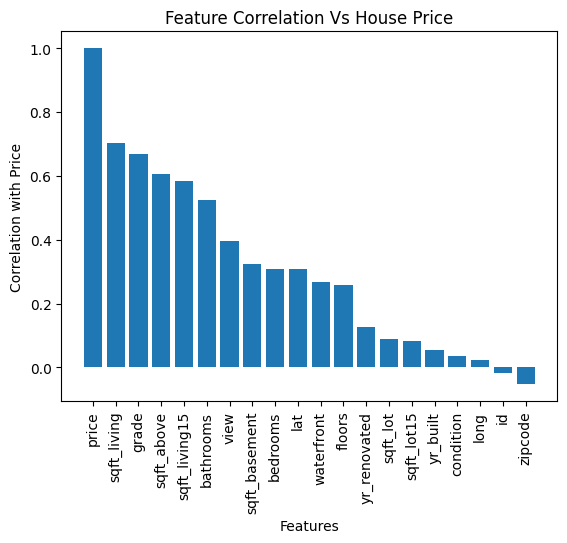

In [11]:
plt.title("Feature Correlation Vs House Price")

data = data.drop(['date'],axis=1)
correlation_matrix = data.corr()                                                      # Generate the correlation matrix for the dataset
sorted_features = correlation_matrix['price'].sort_values(ascending=False).index      # Filter for how the features correlate to price and sort them in descending order

plt.bar(sorted_features, correlation_matrix.loc[sorted_features, ['price']]['price'])
plt.xlabel('Features')
plt.ylabel('Correlation with Price')
plt.xticks(rotation=90)
plt.show()

This plot shows how heavily correlated each feature is with the price. It shows that features relating to the square footage, grade and the number of bathrooms are the most heavily correlated features. This aligns with common intuition that larger houses and houses built to a higher standard, command higher prices.

As expected, ID and Zipcode do not have any correlation because they are categoric identifiers rather than numeric measurements. Therefore Pearson correlation is not meaningful for these features.

Surprisingly condition does not appear to have strong correlation. This could indicate that other factors like location and size are stronger determinants, as the condition can be improved with renovations, but the location cannot.

The number of bedrooms is ranked lower than expected, as it the latitude and longitude. The latitude and longitude are likely misplaced because, in isolation, they might not reveal much correlation, but in combination they show the exact location of the property, and the map plot shows a clear correlation between location and price.

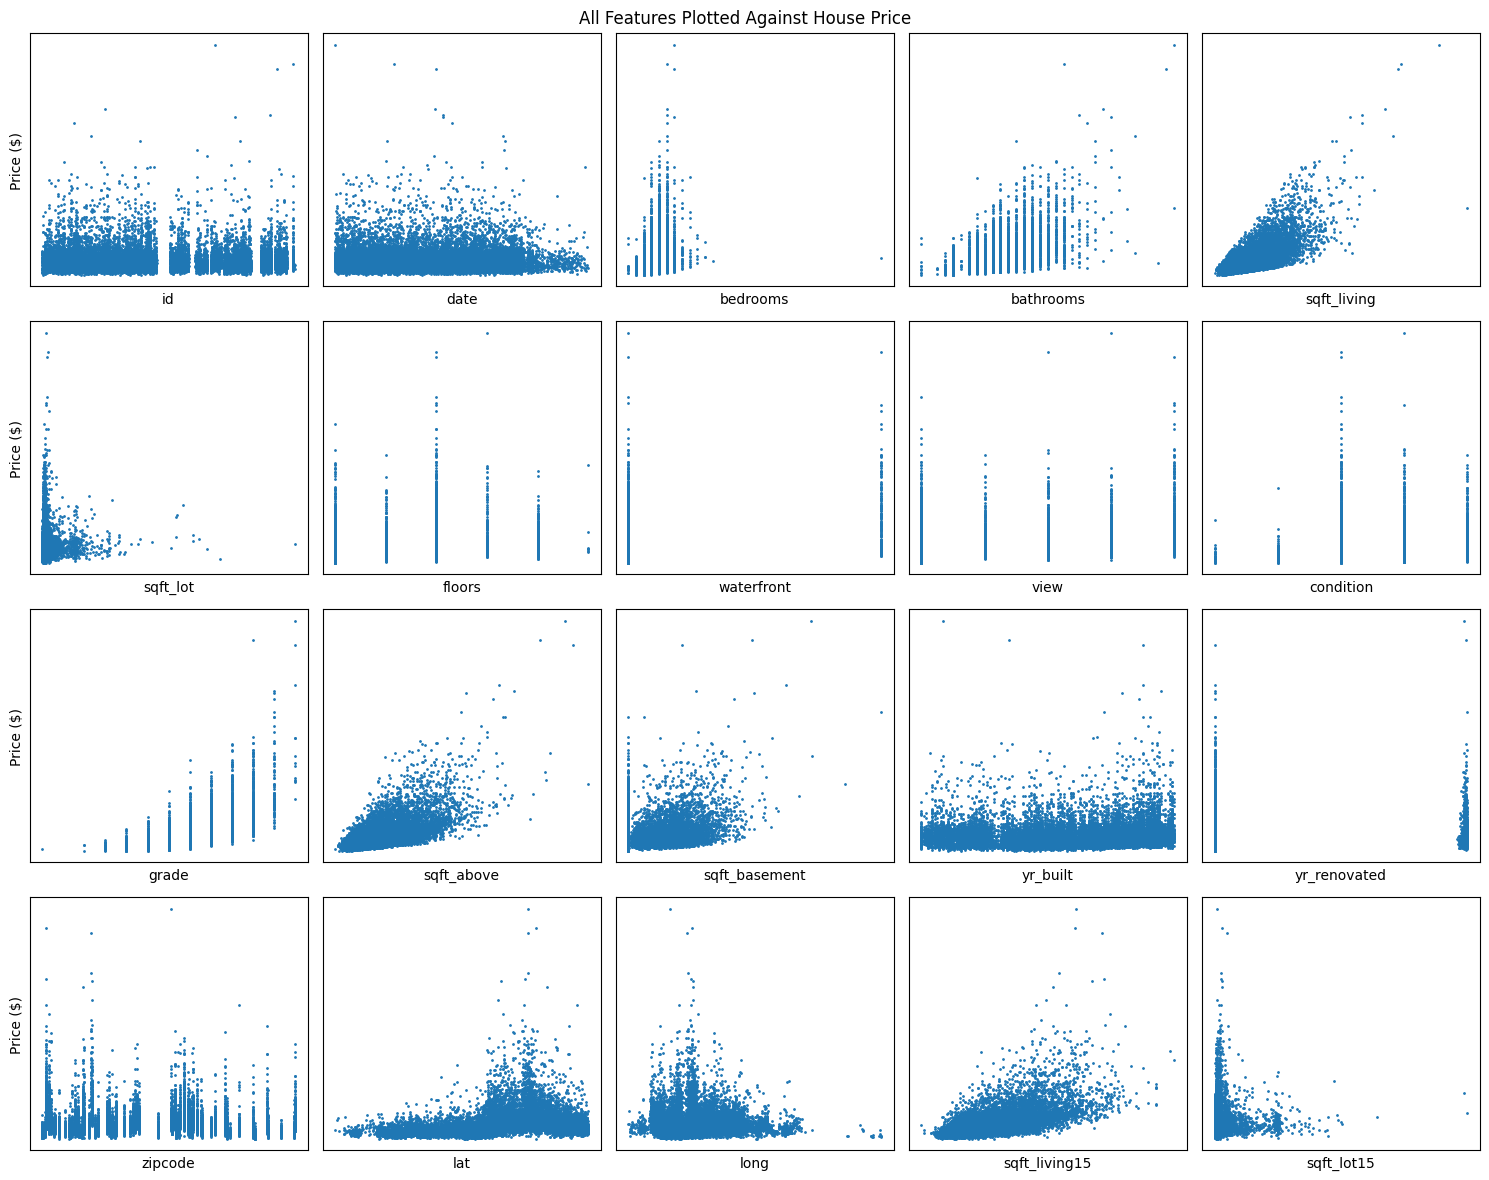

In [12]:
subplot_h = 3
subplot_w = 3

rows = 4
cols = 5

plt.figure(figsize=(subplot_w*cols, (subplot_h*rows)))    # Set the size of the figure

plt.suptitle("All Features Plotted Against House Price")

for i, column in enumerate(X.columns): # Go through every feature
    
    if (i-1) % cols == 0:           # Only show a ylabel at the start of each row
        plt.ylabel("Price ($)")
        
    plt.subplot(4, 5, i+1)
    plt.scatter(X[column], y, s=1) # Plot the feature against the price
    
    plt.xlabel(column)
    
    plt.xticks([])                 # Remove the ticks
    plt.yticks([])

plt.tight_layout()
plt.show()

These plots further illustrate some of the relationships:
- Features relating to square footage all seem to have a positive correlation
- Grade has a positive correlation which almost appears exponential
- Number of bathrooms has a positive correlation
- Number of bedrooms has a positive correlation, but beyond 6 bedrooms the trend isn't as strong

## Feature Decisions

Overall it is clear that the square footage is a strong indicator. However, six different features, all relating to the floor/lot area may be conflated and introduce redundancy into the model. Requiring all of these variations from the end user is also unreasonable. The best approach from a UI perspective is to only use the square footage of the interior and maybe the plot area too.

Another trend is that the geographical location plays a key role in determining property value. The latitude and longitude are the best numerical representation of this. While asking the user for this information may be confusing, the input method can be made more intuitive through an interactive map or geocoding a provided zip code.

The number of bedrooms and bathrooms are intuitive metrics which appear to correlate with price. The only potential confusion is the use of the North American system for counting bathrooms. However, provided that the user is informed of this system, these fields should be easy for them to fill out.

The Kings County Grading System gives a strong indication of the standard of the building and therefore the price. The issue is that a professional surveyor is needed to score the property and the system is specific to Kings County. While it is likely that any model trained on this data will learn the trends of this specific, local housing market, the aim is to keep the user inputs as general as possible. 

Overall, the goal of this project is not to produce the most accurate model possible, but to produce a model that can be driven by a small number of intuitive inputs that a prospective homebuyer can realistically provide. With that in mind, the chosen features are:
- sqft_living
- latitude
- longitude
- bedrooms
- bathrooms

In [13]:
selected_features = [
    "sqft_living",
    "lat",
    "long",
    "bedrooms",
    "bathrooms"
]

X_selected = X[selected_features]

X_selected.head()

,sqft_living,lat,long,bedrooms,bathrooms
0,1180,47.5112,-122.257,3,1.00
1,2570,47.7210,-122.319,3,2.25
2,770,47.7379,-122.233,2,1.00
3,1960,47.5208,-122.393,4,3.00
4,1680,47.6168,-122.045,3,2.00
